# Fase 2: modelo de popularidad de combinaciones

**Objetivo:** estimar qué tanto se juega **cualquier** combinación de 6 números, para elegir combinaciones poco jugadas y no compartir el premio si se gana.

**El modelo** (`src/popularidad.py`) supone que cada combinación jugada viene de una mezcla:
- una fracción **q** se elige **al azar** (la máquina elige por la persona);
- el resto la elige la gente, y cada número *i* tiene un **peso aᵢ**: una combinación se juega en proporción al producto de los pesos de sus 6 números, multiplicado por **γ** por cada pareja de consecutivos y por **δ** por cada par de números en la misma decena (la gente evita los consecutivos y reparte sus números; ver sección 5).

Con este supuesto se puede calcular **exactamente** cuántos ganadores de 2, 3, 4 y 5 aciertos se esperan para cualquier combinación ganadora. El modelo se ajusta comparando esos esperados con los ganadores reales de 2,870 combinaciones ganadoras (Melate y Revancha, 2014–2026), con pérdida robusta (Huber) para que atípicos como el concurso 4105 no lo arrastren.

**Validación honesta, por tiempo:** se entrena con 2014–2020, se elige la regularización con 2021–2022 y se evalúa **una sola vez** con 2023–2026, sorteos que el modelo nunca vio.

### Resumen
- **Precisión:** con sorteos de 2023–2026 que nunca vio, el modelo final explica **53–56%** de la variación de la popularidad (ρ = 0.84 con 3 aciertos y 0.74 con 4). Es casi lo mismo que un boosting (R² 0.54–0.60), con solo 59 parámetros interpretables, y además calcula la popularidad de **cualquier** combinación.
- **Cómo juega la gente:**
  - ~**60%** de las combinaciones se juegan al azar.
  - Entre el resto, el **7** es el favorito (2.7 veces el promedio), seguido del 13, 9, 3, 12 y 8. Los menos elegidos son 40, 50, 49, 51 y 48 (~0.35×).
  - Cada pareja de consecutivos multiplica la popularidad por **0.54**, y cada par de números en la misma decena por **0.83**.
  - Los pesos son estables en el tiempo (correlación 0.986 entre 2014–2019 y 2020–2026).
- **Beneficio:** las combinaciones del generador (10% menos jugado) cobrarían en promedio **~26% más con 4 aciertos y ~36% más con 5** que una combinación al azar. En el premio mayor no hay diferencia práctica.
- **Limitación:** el modelo no conoce patrones especiales como 1-2-3-4-5-6, así que el generador y la app los manejan con reglas aparte.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import estilo, datos
from estilo import COLORES, TEORICO, TINTA_2, MUTED
from datos import N_COLS
from popularidad import ModeloPesos, ModeloPopularidad, combinaciones_al_azar, C_TOTAL

estilo.aplicar()
FIG_DIR = ROOT / "reports" / "figures"
MODELOS = ROOT / "models"; MODELOS.mkdir(exist_ok=True)
pd.set_option("display.width", 160)
rng = np.random.default_rng(2026)


def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png")


pr, _ = datos.cargar_premios()
hist = datos.cargar_historico()
d = datos.popularidad(pr).merge(hist[["concurso", "juego", *N_COLS]], on=["concurso", "juego"]).sort_values(["fecha", "juego"]).reset_index(drop=True)
W = d[N_COLS].to_numpy()
G = d[[2, 3, 4, 5]].to_numpy(float)          # ganadores con 2, 3, 4 y 5 aciertos
d["conjunto"] = np.select([d.fecha < "2021-01-01", d.fecha < "2023-01-01"], ["entrenamiento", "validación"], "prueba")
d.groupby("conjunto", sort=False).agg(observaciones=("concurso", "size"), desde=("fecha", "min"), hasta=("fecha", "max"))

,observaciones,desde,hasta
conjunto,,,
entrenamiento,1194,2014-06-01,2020-12-30
validación,512,2021-01-03,2022-12-30
prueba,1164,2023-01-01,2026-10-02


## 1. Modelos de comparación
Para saber si el modelo estructural aporta algo, se compara con alternativas más simples. Todas predicen el índice de popularidad observado en escala log (log R₃ y log R₄; R = ganadores observados / esperados si todos jugaran al azar).
- **Constante:** R = 1, todas las combinaciones igual de populares.
- **Solo fechas:** regresión lineal sobre cuántos números son ≤31.
- **Boosting:** gradient boosting con 56 indicadores (uno por número) más rasgos de patrón (suma, consecutivos, terminaciones, decenas, etc.).
- **Estructural, solo números:** pesos por número con fracción al azar.
- **Estructural, números + patrones:** lo anterior más γ (consecutivos) y δ (misma decena). Es el que se usa al final, porque calcula la popularidad de cualquier combinación de forma coherente.

In [2]:
def rasgos(X):
    X = np.sort(X, axis=1)
    uno = np.zeros((len(X), 56)); uno[np.arange(len(X))[:, None], X - 1] = 1
    dif = np.diff(X, axis=1)
    patron = np.c_[(X <= 31).sum(1), (X <= 12).sum(1), (X > 49).sum(1), (dif == 1).sum(1), X.sum(1), X[:, -1] - X[:, 0],
                   [np.bincount(r % 10, minlength=10).max() for r in X], [len(set(r // 10)) for r in X], (X % 7 == 0).sum(1)]
    return np.c_[uno, patron]


Y = np.log(d[["R3", "R4"]].to_numpy())
F = rasgos(W)
idx = {c: (d.conjunto == c).to_numpy() for c in ["entrenamiento", "validación", "prueba"]}


def metricas(y, p):
    return {"R²": 1 - ((y - p) ** 2).sum() / ((y - y.mean()) ** 2).sum(), "ρ Spearman": stats.spearmanr(y, p)[0]}


def evaluar(pred, en):
    out = {}
    for j, k in enumerate((3, 4)):
        for nombre, v in metricas(Y[en, j], pred[:, j]).items():
            out[(f"{k} aciertos", nombre)] = v
    return out


def ajustar_todos(tr, lam):
    simple = ModeloPesos(lam=lam).fit(W[tr], G[tr])
    m = ModeloPopularidad(lam=lam).fit(W[tr], G[tr])
    lin = [LinearRegression().fit(F[tr][:, [56]], Y[tr, j]) for j in range(2)]
    gb = [HistGradientBoostingRegressor(learning_rate=0.05, max_iter=400, max_leaf_nodes=15, l2_regularization=1.0,
                                        early_stopping=True, random_state=0).fit(F[tr], Y[tr, j]) for j in range(2)]
    return {
        "Constante (R = 1)": lambda en: np.zeros((en.sum(), 2)),
        "Solo fechas (≤31)": lambda en: np.column_stack([l.predict(F[en][:, [56]]) for l in lin]),
        "Boosting (56 números + patrones)": lambda en: np.column_stack([b.predict(F[en]) for b in gb]),
        "Estructural: solo números": lambda en: np.log(simple.R(W[en])[:, :2]),
        "Estructural: números + patrones": lambda en: np.log(m.R(W[en])[:, :2]),
    }, m

## 2. Elección de la regularización (entrenamiento 2014–2020, validación 2021–2022)

In [3]:
filas = []
for lam in (1, 3, 10):
    m = ModeloPopularidad(lam=lam).fit(W[idx["entrenamiento"]], G[idx["entrenamiento"]])
    p = np.log(m.R(W[idx["validación"]])[:, :2])
    filas.append({"λ": lam, "q (fracción al azar)": m.q, **evaluar(p, idx["validación"])})
val = pd.DataFrame(filas).set_index("λ")
LAM = val[("4 aciertos", "R²")].idxmax()
print(f"λ elegido con validación: {LAM}")
val.round(3)

λ elegido con validación: 1


,q (fracción al azar),"(3 aciertos, R²)","(3 aciertos, ρ Spearman)","(4 aciertos, R²)","(4 aciertos, ρ Spearman)"
λ,,,,,
1,0.605,0.684,0.805,0.467,0.664
3,0.589,0.685,0.805,0.466,0.663
10,0.544,0.685,0.805,0.461,0.661


## 3. Evaluación final con sorteos nunca vistos (2023–2026)

In [4]:
tr = idx["entrenamiento"] | idx["validación"]
modelos, m_tr = ajustar_todos(tr, LAM)
te = idx["prueba"]
evaluacion = pd.DataFrame({nombre: evaluar(f(te), te) for nombre, f in modelos.items()}).T
print(f"Entrenamiento: {tr.sum()} combinaciones ganadoras (2014–2022) | prueba: {te.sum()} (2023–2026)")
evaluacion.round(3)

Entrenamiento: 1706 combinaciones ganadoras (2014–2022) | prueba: 1164 (2023–2026)


3 aciertos            4 aciertos           
                                         R² ρ Spearman         R² ρ Spearman
Constante (R = 1)                    -0.008        NaN     -0.037        NaN
Solo fechas (≤31)                     0.290      0.645      0.275      0.528
Boosting (56 números + patrones)      0.541      0.855      0.600      0.770
Estructural: solo números             0.454      0.778      0.450      0.639
Estructural: números + patrones       0.531      0.840      0.562      0.737

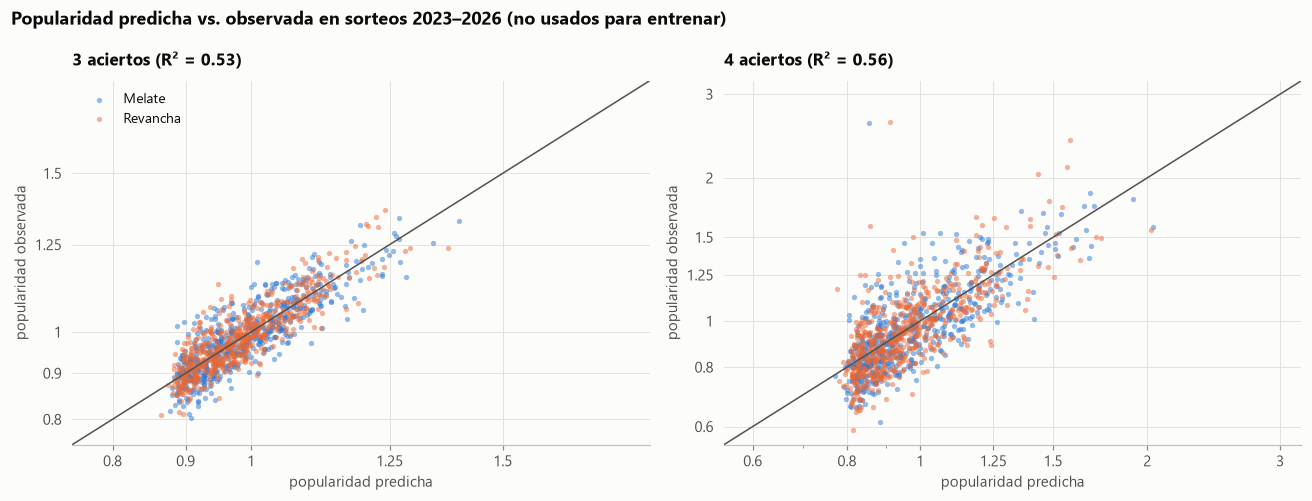

In [5]:
p_est = modelos["Estructural: números + patrones"](te)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for j, (ax, k) in enumerate(zip(axes, (3, 4))):
    for juego in ["Melate", "Revancha"]:
        s = (d.loc[te, "juego"] == juego).to_numpy()
        ax.scatter(np.exp(p_est[s, j]), np.exp(Y[te][s, j]), s=12, alpha=0.5, lw=0, color=COLORES[juego], label=juego)
    lims = [0.55, 3.2] if k == 4 else [0.75, 1.9]
    ax.plot(lims, lims, color=TEORICO, lw=1)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
    marcas = [0.6, 0.8, 1, 1.25, 1.5, 2, 3] if k == 4 else [0.8, 0.9, 1, 1.25, 1.5]
    for eje in (ax.xaxis, ax.yaxis):
        eje.set_major_locator(mticker.FixedLocator(marcas)); eje.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
        eje.set_minor_formatter(mticker.NullFormatter())
    ax.grid(True, axis="both")
    r = evaluacion.loc["Estructural: números + patrones", (f"{k} aciertos", "R²")]
    ax.set_title(f"{k} aciertos (R² = {r:.2f})", fontsize=11)
    ax.set_xlabel("popularidad predicha"); ax.set_ylabel("popularidad observada")
axes[0].legend(loc="upper left")
fig.suptitle("Popularidad predicha vs. observada en sorteos 2023–2026 (no usados para entrenar)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
guardar(fig, "14_modelo_pred_vs_obs")
plt.show()

**Lectura:**
- **Lo que no sirve:** la constante (R² ≈ 0) confirma que sin modelo no se puede predecir nada. Contar números ≤31 ya explica ~28%.
- **Lo que sí:** el modelo de solo números explica ~45%, y agregarle consecutivos y decenas lo sube a **53–56%**, cerca del boosting.
- **Por qué se usa el estructural:** el boosting predice un poco mejor la popularidad de las *combinaciones ganadoras*, pero no sirve para lo que se necesita. Para calcular el premio esperado de una combinación hay que saber cuántos ganadores habría en *cualquier* sorteo posible, y eso solo lo da un modelo de cómo se eligen las combinaciones. Además, sus 59 parámetros se pueden leer y revisar.
- **Regularización:** casi no importa (λ = 1, 3 y 10 dan el mismo R²). Mueve un poco la fracción al azar estimada (0.54–0.61), que es el parámetro menos preciso.
- En la gráfica, Melate y Revancha caen sobre la misma diagonal. Tiene sentido, porque son los mismos boletos.

## 4. ¿Qué números juega la gente?

Fracción estimada de combinaciones al azar: q = 0.60
Cada pareja de consecutivos multiplica la popularidad por γ = 0.54; cada par de números en la misma decena, por δ = 0.83


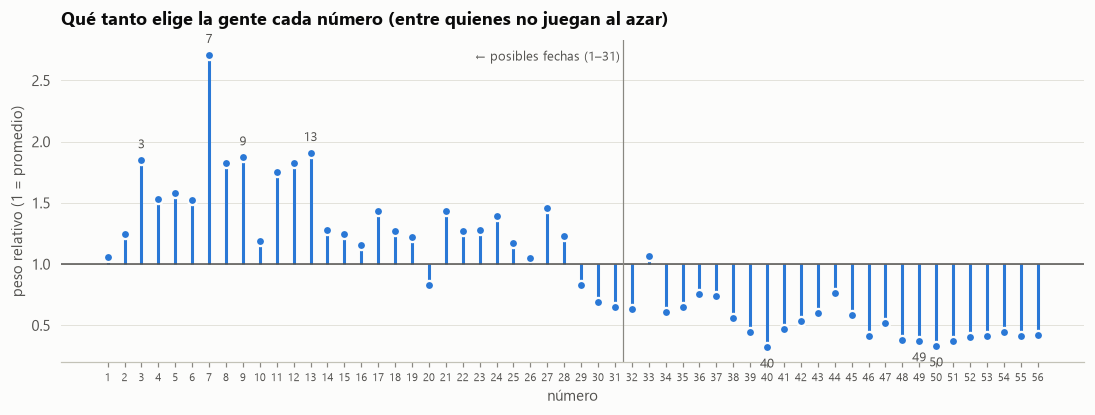

,más elegidos,menos elegidos
0,7 (2.71),40 (0.32)
1,13 (1.91),50 (0.33)
2,9 (1.87),49 (0.37)
3,3 (1.85),51 (0.37)
4,12 (1.83),48 (0.38)
5,8 (1.82),52 (0.40)
6,11 (1.75),53 (0.41)
7,5 (1.58),55 (0.41)
8,4 (1.53),46 (0.42)
9,6 (1.53),56 (0.42)


In [6]:
# Modelo final: todos los datos 2014–2026 con el λ elegido
modelo = ModeloPopularidad(lam=LAM).fit(W, G)
modelo.guardar(MODELOS / "popularidad_melate.npz", desde=str(d.fecha.min().date()), hasta=str(d.fecha.max().date()))
pesos = pd.Series(modelo.pesos, index=pd.RangeIndex(1, 57, name="número"), name="peso")
print(f"Fracción estimada de combinaciones al azar: q = {modelo.q:.2f}")
print(f"Cada pareja de consecutivos multiplica la popularidad por γ = {modelo.gamma:.2f}; cada par de números en la misma decena, por δ = {modelo.delta_decena:.2f}")

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.vlines(pesos.index, 1, pesos.values, color=COLORES["Melate"], lw=2)
ax.plot(pesos.index, pesos.values, "o", ms=6, color=COLORES["Melate"], mec="#fcfcfb", mew=1.5)
ax.axhline(1, color=TEORICO, lw=1)
ax.axvline(31.5, color=MUTED, lw=0.8)
ax.annotate("← posibles fechas (1–31)", (31.3, ax.get_ylim()[1] * 0.97), ha="right", va="top", fontsize=8.5, color=TINTA_2)
for n_ in list(pesos.nlargest(4).index) + list(pesos.nsmallest(3).index):
    arriba = pesos[n_] > 1
    ax.annotate(str(n_), (n_, pesos[n_]), xytext=(0, 6 if arriba else -7), textcoords="offset points",
                ha="center", va="bottom" if arriba else "top", fontsize=8.5, color=TINTA_2)
ax.set_xticks(range(1, 57)); ax.tick_params(axis="x", labelsize=7.5)
ax.set_xlabel("número"); ax.set_ylabel("peso relativo (1 = promedio)")
ax.set_title("Qué tanto elige la gente cada número (entre quienes no juegan al azar)")
guardar(fig, "15_pesos_por_numero")
plt.show()
pd.DataFrame({"más elegidos": [f"{n} ({pesos[n]:.2f})" for n in pesos.nlargest(10).index],
              "menos elegidos": [f"{n} ({pesos[n]:.2f})" for n in pesos.nsmallest(10).index]})

In [7]:
# Estabilidad: ¿los pesos cambian con el tiempo? Se ajusta por separado 2014–2019 y 2020–2026
a = ModeloPopularidad(lam=LAM).fit(W[(d.fecha < "2020-01-01").to_numpy()], G[(d.fecha < "2020-01-01").to_numpy()])
b = ModeloPopularidad(lam=LAM).fit(W[(d.fecha >= "2020-01-01").to_numpy()], G[(d.fecha >= "2020-01-01").to_numpy()])
print(f"Correlación de los log-pesos 2014–2019 vs 2020–2026: {np.corrcoef(a.theta, b.theta)[0, 1]:.3f}")
print(f"q: {a.q:.2f} → {b.q:.2f} | γ: {a.gamma:.2f} → {b.gamma:.2f} | δ: {a.delta_decena:.2f} → {b.delta_decena:.2f}")
cambio = pd.DataFrame({"2014–2019": a.pesos, "2020–2026": b.pesos}, index=pesos.index)
cambio.assign(cambio=cambio["2020–2026"] / cambio["2014–2019"]).sort_values("cambio").iloc[[0, 1, 2, -3, -2, -1]].round(2)

Correlación de los log-pesos 2014–2019 vs 2020–2026: 0.986
q: 0.60 → 0.59 | γ: 0.55 → 0.53 | δ: 0.86 → 0.81


,2014–2019,2020–2026,cambio
número,,,
1,1.21,0.99,0.82
36,0.86,0.71,0.83
16,1.23,1.11,0.90
50,0.28,0.36,1.29
39,0.38,0.50,1.31
52,0.33,0.45,1.38


**Lectura:**
- **Juego al azar:** ~60% de las combinaciones se comportan como elegidas al azar. Esto incluye la selección automática y a quienes eligen sin un patrón reconocible.
- **Números favoritos:** el 7 destaca por mucho. Siguen los números bajos (3, 8, 9, 11, 12, 13), que son fechas y números "de la suerte". A partir del 32, todos menos el 33 quedan por debajo del promedio. Del 39 en adelante los pesos van de 0.32 a 0.76, contra 2.7 del 7.
- **Patrones:** la gente **evita los números seguidos** (γ = 0.54 por pareja) y **reparte sus números entre decenas** (δ = 0.83 por par en la misma decena). Por eso las combinaciones con consecutivos o agrupadas se juegan menos.
- **Estabilidad:** los gustos casi no cambian entre 2014–2019 y 2020–2026 (correlación 0.986). Los cambios más visibles son pequeños: el 1 bajó un poco y algunos números altos (39, 50, 52) subieron.

## 5. ¿Qué no captura el modelo?
La primera versión del modelo (solo números) dejaba residuos claramente relacionados con las parejas consecutivas (ρ ≈ −0.39) y con las decenas distintas (ρ ≈ +0.37). Por eso se agregaron γ y δ. Aquí se revisa qué patrón queda sin capturar en los residuos de prueba (observado − predicho) del modelo final.

In [8]:
res = Y[te] - p_est
Xte = np.sort(W[te], axis=1)
patrones = {
    "parejas consecutivas": (np.diff(Xte, axis=1) == 1).sum(1),
    "misma terminación (máx)": [np.bincount(r % 10, minlength=10).max() for r in Xte],
    "decenas distintas": [len(set(r // 10)) for r in Xte],
    "suma": Xte.sum(1),
    "rango (mayor − menor)": Xte[:, -1] - Xte[:, 0],
    "es Revancha": (d.loc[te, "juego"] == "Revancha").astype(int).to_numpy(),
}
pd.DataFrame({f"ρ residuo {k} aciertos": [stats.spearmanr(v, res[:, j])[0] for v in patrones.values()] for j, k in enumerate((3, 4))},
             index=patrones.keys()).round(3)

,ρ residuo 3 aciertos,ρ residuo 4 aciertos
parejas consecutivas,-0.059,-0.075
misma terminación (máx),-0.140,-0.164
decenas distintas,0.176,0.192
suma,0.085,0.081
rango (mayor − menor),0.040,0.018
es Revancha,0.052,0.023


**Lectura:** con γ y δ, la relación de los residuos con los consecutivos casi desaparece (de −0.39 a −0.07), y con las decenas baja de +0.37 a +0.18. Queda un efecto menor: la gente también evita repetir terminaciones (−0.15) y reparte sus números todavía más de lo que captura δ. Es una mejora posible para una versión futura, pero el efecto es pequeño. Melate y Revancha no difieren (ρ ≈ 0.02–0.05).

## 6. Popularidad de cualquier combinación
Con el modelo se puede calcular la popularidad de cualquiera de las 32,468,436 combinaciones (1 = se juega como una combinación promedio).

Distribución de la popularidad entre todas las combinaciones:
1%     0.604
10%    0.627
25%    0.673
50%    0.796
75%    1.076
90%    1.582
99%    3.507


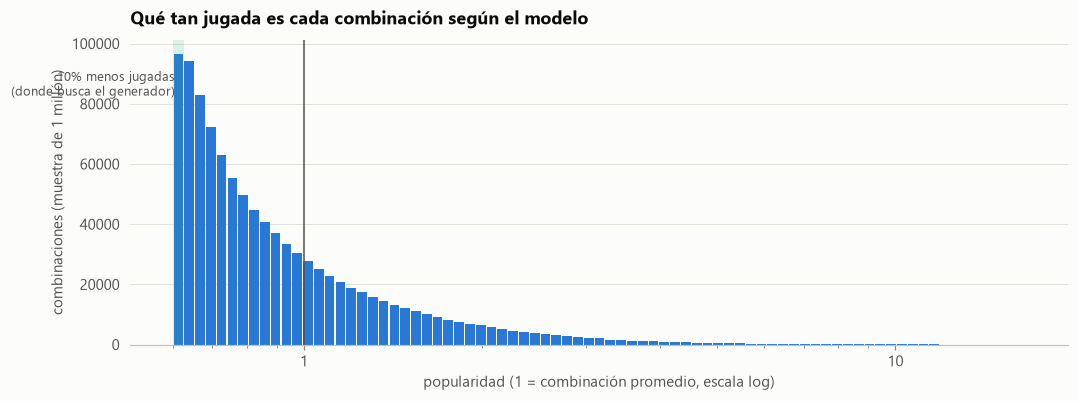

In [9]:
muestra = combinaciones_al_azar(1_000_000, rng)
pop = modelo.popularidad(muestra)
cuantiles = pd.Series(np.quantile(pop, [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]), index=["1%", "10%", "25%", "50%", "75%", "90%", "99%"])
print("Distribución de la popularidad entre todas las combinaciones:")
print(cuantiles.round(3).to_string())
UMBRAL = cuantiles["10%"]

fig, ax = plt.subplots(figsize=(11, 3.6))
bins = np.geomspace(pop.min(), pop.max(), 80)
ax.hist(pop, bins=bins, color=COLORES["Melate"], rwidth=0.9)
ax.axvspan(pop.min(), UMBRAL, color=COLORES["Revanchita"], alpha=0.15, lw=0)
ax.annotate("10% menos jugadas\n(donde busca el generador)", (UMBRAL, ax.get_ylim()[1] * 0.9), xytext=(-6, 0),
            textcoords="offset points", ha="right", va="top", fontsize=8.5, color=TINTA_2)
ax.axvline(1, color=TEORICO, lw=1)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("popularidad (1 = combinación promedio, escala log)"); ax.set_ylabel("combinaciones (muestra de 1 millón)")
ax.set_title("Qué tan jugada es cada combinación según el modelo")
guardar(fig, "16_distribucion_popularidad")
plt.show()

In [10]:
ejemplos = {
    "Los 6 números más elegidos": np.sort(pesos.nlargest(6).index.to_numpy()),
    "Fechas típicas (3-7-12-15-21-28)": np.array([3, 7, 12, 15, 21, 28]),
    "1-2-3-4-5-6": np.arange(1, 7),
    "Mezcla típica (5-14-23-32-41-50)": np.array([5, 14, 23, 32, 41, 50]),
    "Altos (36-42-47-51-53-56)": np.array([36, 42, 47, 51, 53, 56]),
    "Los 6 números menos elegidos": np.sort(pesos.nsmallest(6).index.to_numpy()),
}
pd.DataFrame({"combinación": ["-".join(map(str, c)) for c in ejemplos.values()],
              "popularidad": modelo.popularidad(np.array(list(ejemplos.values()))),
              "percentil": [(pop < p_).mean() * 100 for p_ in modelo.popularidad(np.array(list(ejemplos.values())))]},
             index=ejemplos.keys()).round(2)

,combinación,popularidad,percentil
Los 6 números más elegidos,3-7-8-9-12-13,2.87,98.07
Fechas típicas (3-7-12-15-21-28),3-7-12-15-21-28,11.21,100.00
1-2-3-4-5-6,1-2-3-4-5-6,0.63,9.63
Mezcla típica (5-14-23-32-41-50),5-14-23-32-41-50,0.84,55.73
Altos (36-42-47-51-53-56),36-42-47-51-53-56,0.61,1.66
Los 6 números menos elegidos,40-48-49-50-51-52,0.60,0.00


**Lectura:**
- La mitad de las combinaciones se juega menos que el promedio (mediana 0.80). La razón es que unas pocas combinaciones muy populares concentran muchos boletos: el 1% más jugado está por encima de **3.5×**.
- Unas fechas típicas (3-7-12-15-21-28) se juegan **11 veces** más que el promedio.
- ⚠️ **1-2-3-4-5-6 sale "poco jugada" (0.63×), y eso casi seguro es falso.** El modelo aprendió que la gente evita los consecutivos y lo aplica a una secuencia que mucha gente juega a propósito. Es un límite del modelo: no conoce patrones especiales que casi nunca salen sorteados, así que nunca los ha medido. Por eso el generador excluye secuencias, progresiones y combinaciones ganadoras anteriores, y la app avisa cuando aparecen en lugar de calificarlas como poco jugadas.

## 7. Generador y beneficio esperado
El generador elige **al azar** entre las combinaciones del 10% menos jugado. No elige "la" menos jugada, porque si mucha gente usara la misma regla esa combinación se volvería popular. Además excluye patrones que el modelo no ve pero que la gente juega mucho (reglas de prudencia, **no aprendidas de los datos**): combinaciones ganadoras anteriores, 3 o más consecutivos y progresiones aritméticas.

**Beneficio:** si ganas con *k* aciertos, tu premio es la bolsa de esa categoría dividida entre todos los ganadores. Con el modelo se calcula cuántos ganadores esperarías, en promedio sobre todos los sorteos posibles en los que tu combinación acierta *k* números, y se compara contra una combinación al azar.

In [11]:
ganadoras_previas = set(map(tuple, np.sort(hist[N_COLS].to_numpy(), axis=1)))


def es_patron(c):
    dif = np.diff(c)
    racha = max(len(s) for s in "".join("1" if x == 1 else "0" for x in dif).split("0")) + 1
    return tuple(c) in ganadoras_previas or racha >= 3 or len(set(dif)) == 1


def generar(n, umbral=UMBRAL, rng=rng):
    salida = []
    while len(salida) < n:
        cand = combinaciones_al_azar(20_000, rng)
        cand = cand[modelo.popularidad(cand) <= umbral]
        salida += [c for c in cand if not es_patron(c)][: n - len(salida)]
    return np.array(salida)


sugeridas = generar(10)
pd.DataFrame({"combinación": ["-".join(f"{x:02d}" for x in c) for c in sugeridas], "popularidad": modelo.popularidad(sugeridas).round(3)})

,combinación,popularidad
0,06-35-36-43-50-53,0.621
1,04-12-48-50-51-56,0.616
2,05-30-31-35-46-51,0.621
3,02-23-40-44-46-47,0.614
4,11-40-43-45-52-54,0.616
5,25-26-34-39-43-49,0.621
6,15-17-44-53-55-56,0.623
7,23-25-44-46-49-50,0.614
8,19-20-24-39-40-43,0.623
9,20-33-37-38-45-50,0.620


In [12]:
V = d.loc[d.juego == "Melate", "V"].median()  # combinaciones jugadas por sorteo (mediana)


def reparto_esperado(C, k, muestras=300, rng=rng):
    """Fracción esperada de la bolsa de la categoría k que recibe cada combinación C si acierta k números:
    E[1/(1+X)], X ~ Poisson(otros ganadores), promediando sobre sorteos w con |c∩w| = k."""
    M = len(C)
    rep = np.repeat(C, muestras, axis=0)
    resto = np.array([np.setdiff1d(np.arange(1, 57), c) for c in C]).repeat(muestras, axis=0)
    elige = lambda A, m_: np.take_along_axis(A, rng.random(A.shape).argsort(axis=1)[:, :m_], axis=1)
    Wk = np.sort(np.c_[elige(rep, k), elige(resto, 6 - k)], axis=1)
    lam_ = V * modelo.prob(Wk)[:, k]
    return ((1 - np.exp(-lam_)) / lam_).reshape(M, muestras).mean(axis=1)


grupos = {
    "Al azar (referencia)": combinaciones_al_azar(400, rng),
    "Generador (10% menos jugado)": generar(400),
    "10% más jugado": (lambda c: c[modelo.popularidad(c) >= cuantiles["90%"]][:400])(combinaciones_al_azar(20_000, rng)),
}
filas = {}
for nombre, C in grupos.items():
    fila = {f"{k} aciertos": reparto_esperado(C, k).mean() for k in (4, 5)}
    lam6 = V * modelo.popularidad(C) / C_TOTAL  # otros ganadores esperados del premio mayor con tu misma combinación
    fila["6 aciertos (premio mayor)"] = ((1 - np.exp(-lam6)) / lam6).mean()
    filas[nombre] = fila
reparto = pd.DataFrame(filas).T
beneficio = reparto / reparto.loc["Al azar (referencia)"]
print("Premio esperado por categoría, relativo a jugar una combinación al azar (1.00 = igual):")
beneficio.round(3)

Premio esperado por categoría, relativo a jugar una combinación al azar (1.00 = igual):


,4 aciertos,5 aciertos,6 aciertos (premio mayor)
Al azar (referencia),1.000,1.000,1.000
Generador (10% menos jugado),1.256,1.363,1.006
10% más jugado,0.756,0.598,0.980


**Lectura:**
- **4 y 5 aciertos:** las combinaciones del generador comparten el premio con menos gente. En promedio cobrarían **26% más con 4 aciertos y 36% más con 5** que una combinación al azar. Con una del 10% más jugado, en cambio, cobrarían 24% y 40% menos.
- **Premio mayor:** la diferencia es de menos de 1%. Con ~1 millón de combinaciones jugadas por sorteo, el ganador casi nunca comparte.
- **2 y 3 aciertos:** son premios fijos, así que no cambian.
- **En contexto:** estas categorías son una parte pequeña de lo que se reparte en premios, y el boleto sigue teniendo valor esperado negativo. Elegir bien reduce la pérdida esperada, pero no la elimina.

## 8. Conclusiones

1. **La popularidad de una combinación se puede predecir:** el modelo explica más de la mitad de su variación en sorteos que nunca vio, y es estable en el tiempo.
2. **Lo que juega la gente es muy marcado:** fechas y números bajos (el 7 sobre todo), números separados entre sí y repartidos entre decenas. Casi nadie elige 39–56.
3. **Hay un beneficio real pero acotado:** elegir combinaciones poco jugadas mejora ~25–35% lo que cobrarías en los premios que se reparten (4 y 5 aciertos). No cambia la probabilidad de ganar ni el premio mayor.
4. **Las reglas de prudencia son necesarias:** el modelo no conoce patrones especiales como secuencias o ganadoras anteriores.

**Siguientes pasos posibles:**
- Agregar terminaciones repetidas al modelo.
- Reentrenarlo cada cierto tiempo con sorteos nuevos (`src/scraper.py` → `src/scraper_premios.py` → este notebook → `src/exportar_app.py`).
- Calcular el valor esperado completo del boleto según la bolsa acumulada.